# ```Governance Evidence, Auditability, and Access Reviews```

# 🛡️ Sensitive Embeddings, Metadata, Audit Logs & Access Reviews

The central idea:

> 📌 **Protecting the original documents is not enough.** My embeddings, metadata, caches, and retrieval logs can also become sensitive assets.

---

## 1. Embeddings are not "just vectors"

Imagine the source contains:

```
confidential acquisition plan
```

You turn it into:

```
[0.023, -0.182, 0.441, ...]
```

It looks harmless because humans can't read it. But the embedding was **derived from sensitive information**. So:

```
Sensitive document
       ↓
Embedding
       ↓
Still potentially sensitive
```

The course's mental model is:

> 💡 **An embedding is a compressed fingerprint of the source's meaning.**

It isn't the original document, but it can preserve enough information to matter.

---

## 2. What can actually leak?

There are several risks.

### Inference risk

Someone may infer sensitive properties from:

- similarity behavior
- metadata
- model behavior

### Membership risk

Someone might determine:

```
"Does this sensitive document/person exist in the corpus?"
```

For example, repeatedly probing a search system could reveal whether a particular record is indexed.

### Metadata leakage

This can actually be worse than people expect. Imagine the vector itself is protected, but the API returns:

```
tenant = acquired_company
classification = executive
matter_id = litigation-2026-17
```

You've already leaked sensitive business context.

### Retention mismatch

Source document gets deleted:

```
Source    ❌
Embedding ✅
```

Now the supposedly deleted information still exists in the retrieval layer.

### Privilege expansion

A service account accidentally gets:

```
search_all_tenants = true
```

Now the vector layer has become an **attack surface**.

| Risk | What leaks / goes wrong |
|---|---|
| **Inference** | Sensitive properties inferred from similarity, metadata, model behavior |
| **Membership** | Whether a document/person exists in the corpus |
| **Metadata leakage** | Business context exposed via returned fields |
| **Retention mismatch** | Deleted source still lives on as an embedding |
| **Privilege expansion** | Over-permissioned service account turns vector layer into an attack surface |

These risks and controls are laid out explicitly in the chapter.

---

## 3. Metadata can be MORE dangerous than the vector

This is a really important point. Suppose a chunk has:

```json
{
    "tenant_id": "tenant_alpha",
    "access_tier": "executive",
    "legal_hold": true
}
```

You haven't returned the sensitive text. But you've just told someone:

```
There is an executive-level document under legal hold belonging to tenant Alpha.
```

That's potentially sensitive information by itself.

> 💡 **So metadata needs its own security classification.**

---

## 4. Classify your metadata

The course recommends thinking of metadata **by purpose**:

| Category | Purpose | Example fields |
|---|---|---|
| **Authorization metadata** | Used to determine access | `tenant_id`<br>`group_ids`<br>`entitlement_ids`<br>`classification` |
| **Retrieval metadata** | Used to narrow search | `document_type`<br>`language`<br>`region` |
| **Operational metadata** | Used for lifecycle | `created_at`<br>`pipeline_version`<br>`source_updated_at` |
| **Internal-only metadata** | Should **never** be exposed to the user | — |
| **Metadata that shouldn't exist** | Little value, significant risk | → Don't collect it |

> 📌 That last one is an important security principle: **data minimization**. If a field provides little value but creates significant risk — don't collect it.

---

## 5. Now: Audit Logs

This is the second major part. Imagine something goes wrong.

```
User:      "Why did the system show me this document?"
Security:  "Was this document actually allowed?"
Engineer:  "I think the filter was applied."
Security:  "Which filter?"
Engineer:  "Uh..."
```

😂 That's where audit logs matter.

The course says an audit log should let you reconstruct:

1. **Who** asked
2. **What scope** was applied
3. **What the system considered**
4. **What the system decided**

---

## 6. What should the audit log contain?

At minimum:

```
user / query identity
service identity
tenant
timestamp
filters applied
retrieved chunk/document IDs
allow / deny / suppress decision
administrative changes
```

For example:

```
User: u_18429
Service: retrieval-api-prod
Tenant: tenant_alpha

Policy version: perm-v12

Filters:
    tenant_id = tenant_alpha
    visibility = internal/team-approved

Candidates:
    ch_991  → allow
    ch_1044 → suppress
    ch_2881 → allow

Reason:
    source_permission_mismatch
```

Now if someone asks:

```
"Why wasn't ch_1044 returned?"
```

You have an answer.

The actual course example demonstrates this exact style of structured logging **while redacting the raw query**.

---

## 7. But DON'T log everything

This is another important security lesson. You might think:

```
"For debugging, let's just log the entire query and retrieved documents."
```

**Bad idea.** Imagine the query contains:

- patient information
- legal investigation
- customer secrets
- financial data

Now your audit logs become **a new sensitive database**.

So the course recommends separating:

```
Diagnostic usefulness
        vs
Indiscriminate data capture
```

You might use:

- redaction
- hashing
- normalized summaries
- structured IDs
- different retention periods

instead of storing plaintext sensitive content forever.

### Mental model

> 💡 **Log enough to explain the decision, but not enough to create another copy of the sensitive data.**

---

## 8. Access Reviews

Now we move from:

```
"Can we explain what happened?"
```

to:

```
"Is our security configuration still correct?"
```

Because production systems **drift**. For example:

```
January:
Service account → read metadata only

March:
Someone gives it → broad query access

June:
Nobody remembers why
```

The system still works. But the security posture has **silently degraded**.

That's why you periodically perform an **access review**.

---

## 9. What does an access review check?

### Human access

Does the user's role still match their job?

- Employee changed teams?
- Old permissions removed?

### Service access

Does the service account have **least privilege**?

```
Embedding worker
→ needs write access

Does it need:
→ search every tenant?
→ read raw documents?

Probably not.
```

### Tenant isolation

Can Tenant A ever retrieve Tenant B's content? You don't just inspect configuration — **you run negative tests**. For example:

```
Tenant A query
      ↓
Attempt to retrieve Tenant B document
      ↓
Must fail
```

### Permission freshness

Did source ACL changes propagate?

### Delete propagation

If the source was deleted:

```
source   ❌
vector   ❌
metadata ❌
cache    ❌
replica  ❌
```

Everything relevant needs to disappear.

### Log completeness

Did the required security events actually get recorded?

| Review area | Question |
|---|---|
| **Human access** | Does the user's role still match their job? |
| **Service access** | Does the service account have least privilege? |
| **Tenant isolation** | Can Tenant A ever retrieve Tenant B's content? (negative tests) |
| **Permission freshness** | Did source ACL changes propagate? |
| **Delete propagation** | Did deletes reach vectors, metadata, caches, replicas? |
| **Log completeness** | Did required security events get recorded? |

The course lays out these review areas explicitly.

---

## 10. Negative testing is important

Don't only test:

```
"Can authorized users access authorized documents?"
```

Also test:

```
"Can unauthorized users access forbidden documents?"
```

Example:

```
User A     → Tenant A
Document B → Tenant B

Expected:

Search   → no B
Citation → no B
Metadata → no B
```

**And verify the denial/suppression was logged.**

That's much stronger evidence than simply saying:

```
"Our configuration has tenant filters."
```

| | Positive test | Negative test |
|---|---|---|
| Question | Can authorized users access authorized documents? | Can unauthorized users access forbidden documents? |
| Expected | Access works | No result in search, citation, or metadata — **and** the denial is logged |
| Proves | Feature works | Boundary actually holds |

The chapter explicitly recommends sampling identities and restricted documents, running negative tests, and verifying that denied/suppressed results are logged.

---

## 11. Delete propagation is bigger than the source database

This connects directly to everything we've studied about **tombstones, CDC, freshness and vector lifecycle**. Suppose:

```
Monday:
Document deleted from source

Tuesday:
Vector index still contains embedding

Wednesday:
Cache still contains result
```

Your system is saying:

```
"Deleted."
```

while retrieval is saying:

```
"Here's the document." 💀
```

So deletion needs to cover:

```
Source
 ↓
Vectors
 ↓
Metadata
 ↓
Caches
 ↓
Replicas
```

The course explicitly includes all of these in the **deletion evidence package**.

---

## 12. Evidence that survives an incident

This is the final piece. Suppose there's an incident at 2 AM. You don't want:

```
Engineer:  "I think the ACL sync failed."
Security:  "Can you prove it?"
Engineer:  "..."
```

You want **evidence**. A strong governance package contains:

```
Sensitive metadata policy
        +
Audit log schema
        +
Delete propagation procedure
        +
Access review checklist
        +
Administrative change history
```

The chapter explicitly recommends these artifacts.

---

## 13. Connect this to everything we've learned

We're basically building the security architecture **layer by layer**.

**Earlier:**

```
RAG
 ↓
Vector retrieval
```

**Then:**

```
RAG
 ↓
Retrieval evaluation
 ↓
Recall / Precision / MRR
```

**Then:**

```
Retrieval
 ↓
Observability
 ↓
Drift detection
```

**Then:**

```
Retrieval
 ↓
RBAC
 ↓
Tenant isolation
 ↓
Permission-aware filtering
```

**Now:**

```
Secure Retrieval
       │
       ├── Sensitive embeddings
       │
       ├── Sensitive metadata
       │
       ├── Audit logs
       │
       ├── Delete propagation
       │
       └── Access reviews
```

So we're moving from:

```
"Can I retrieve the right document?"
```

to:

```
"Can I retrieve the right document, for the right person, under the right policy,
 and prove afterward why the system made that decision?"
```

> 📌 **That's production-grade secure RAG.**

---

## 🎯 Priorities

### 🔴 Must know

- Embeddings are **derived data** and can be sensitive.
- Metadata can leak sensitive business/security information.
- Audit logs must capture identity, tenant, filters, retrieved IDs, decisions, and administrative changes.
- Don't blindly log raw queries/content.
- Access reviews check human access, service access, tenant isolation, permission freshness, delete propagation, and log completeness.
- **Negative tests are essential.**
- Deletes must propagate across vectors + metadata + caches + replicas.
- Governance needs **evidence**, not just architecture diagrams.

### 🟡 Understand

- Redaction/hashing
- Different log retention periods
- Metadata classification
- Review cadence based on risk/change velocity

### 🟢 Don't memorize

- Exact JSON audit-log structure
- Exact field names
- The example IDs/timestamps

---

## 🔒 One sentence to remember

> 📌 **Secure RAG isn't just about preventing unauthorized retrieval; it's about making the entire retrieval decision explainable and auditable.**

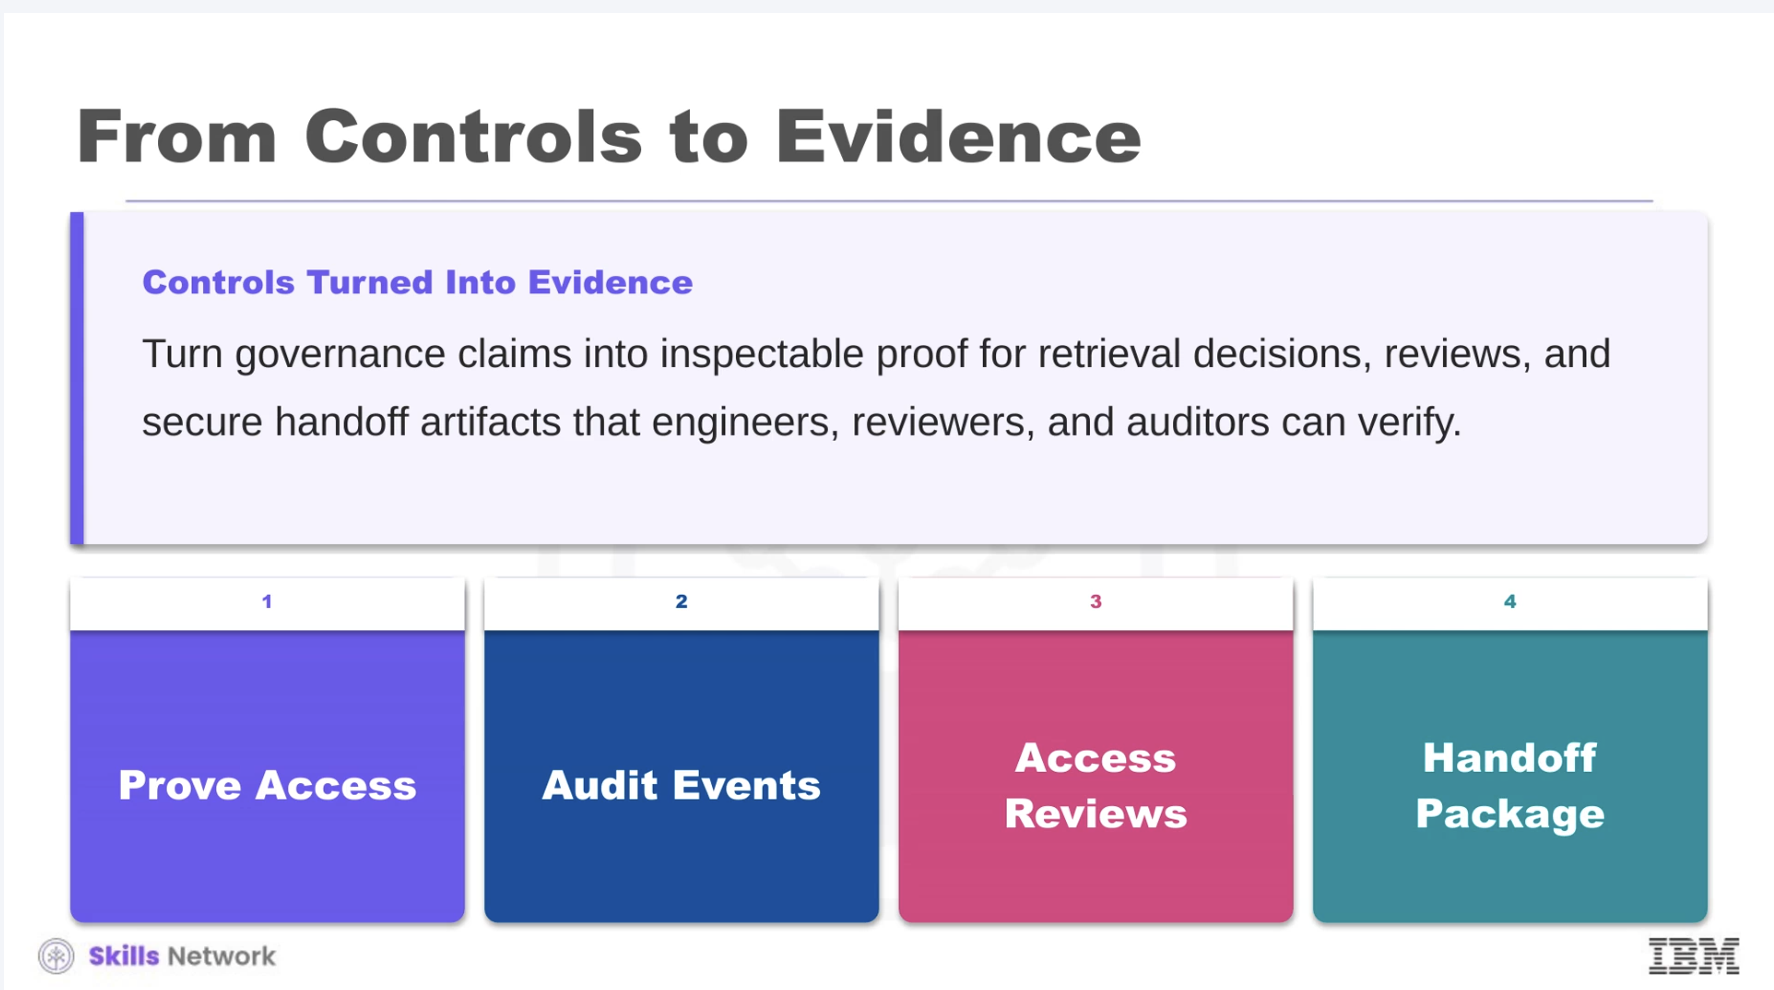
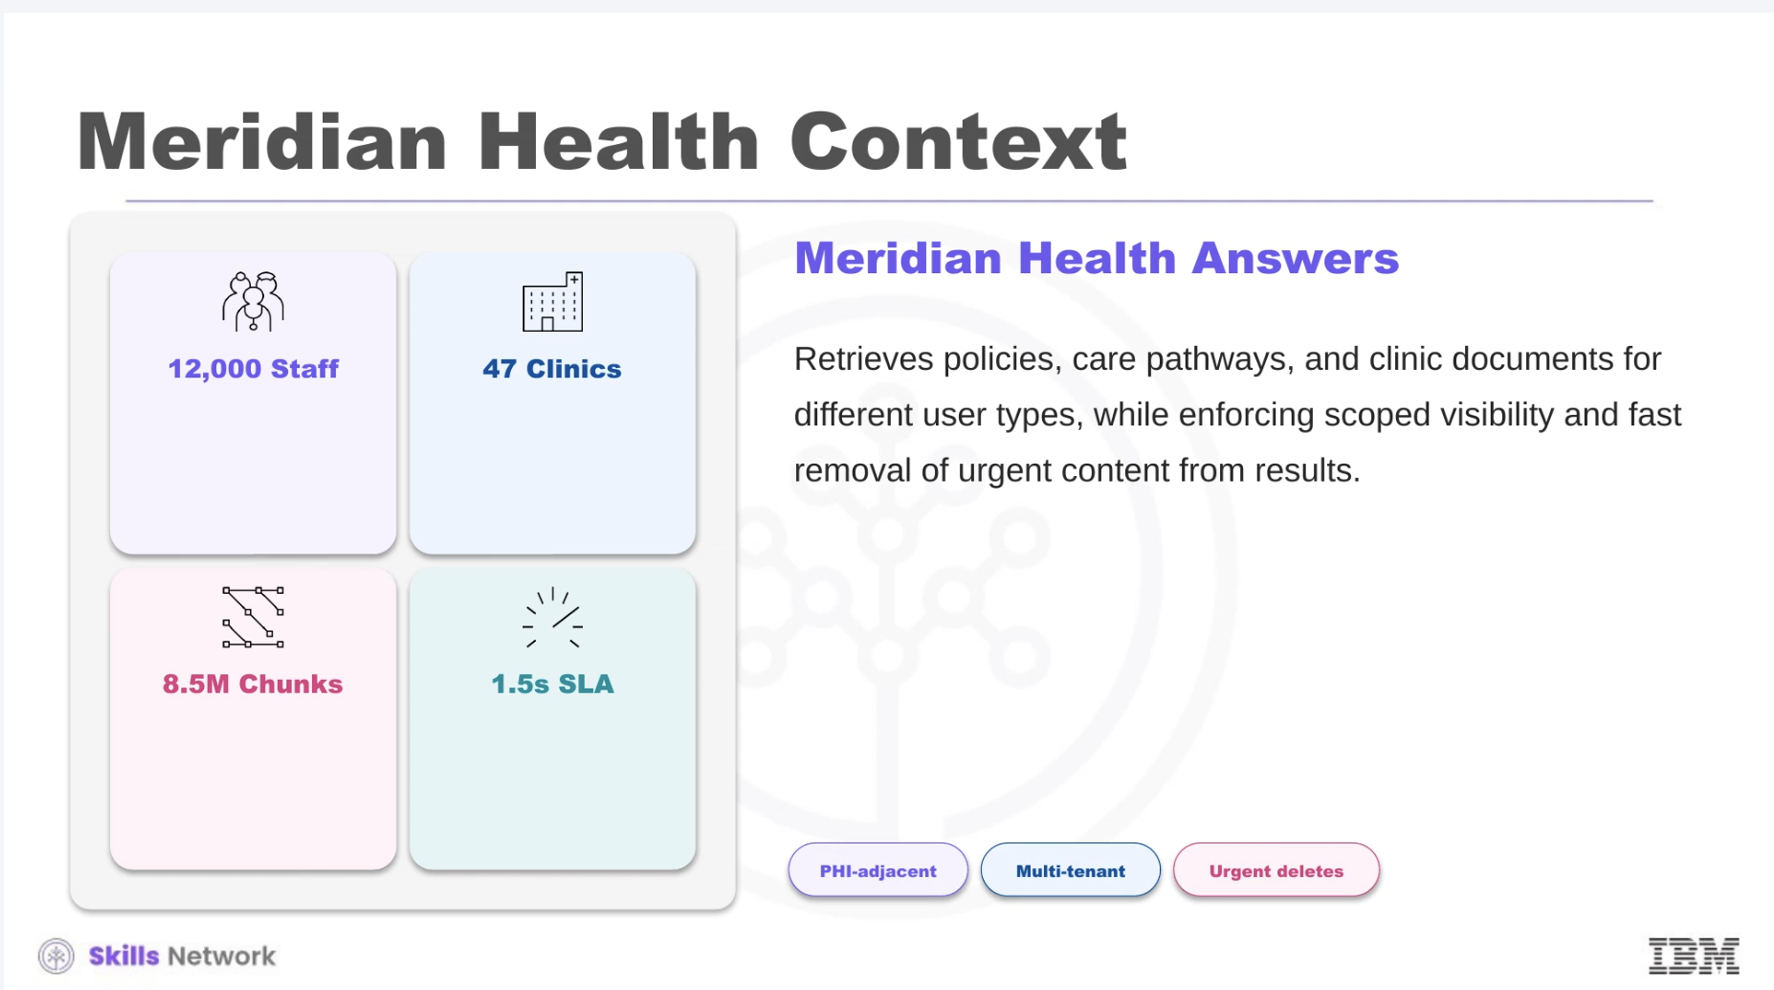
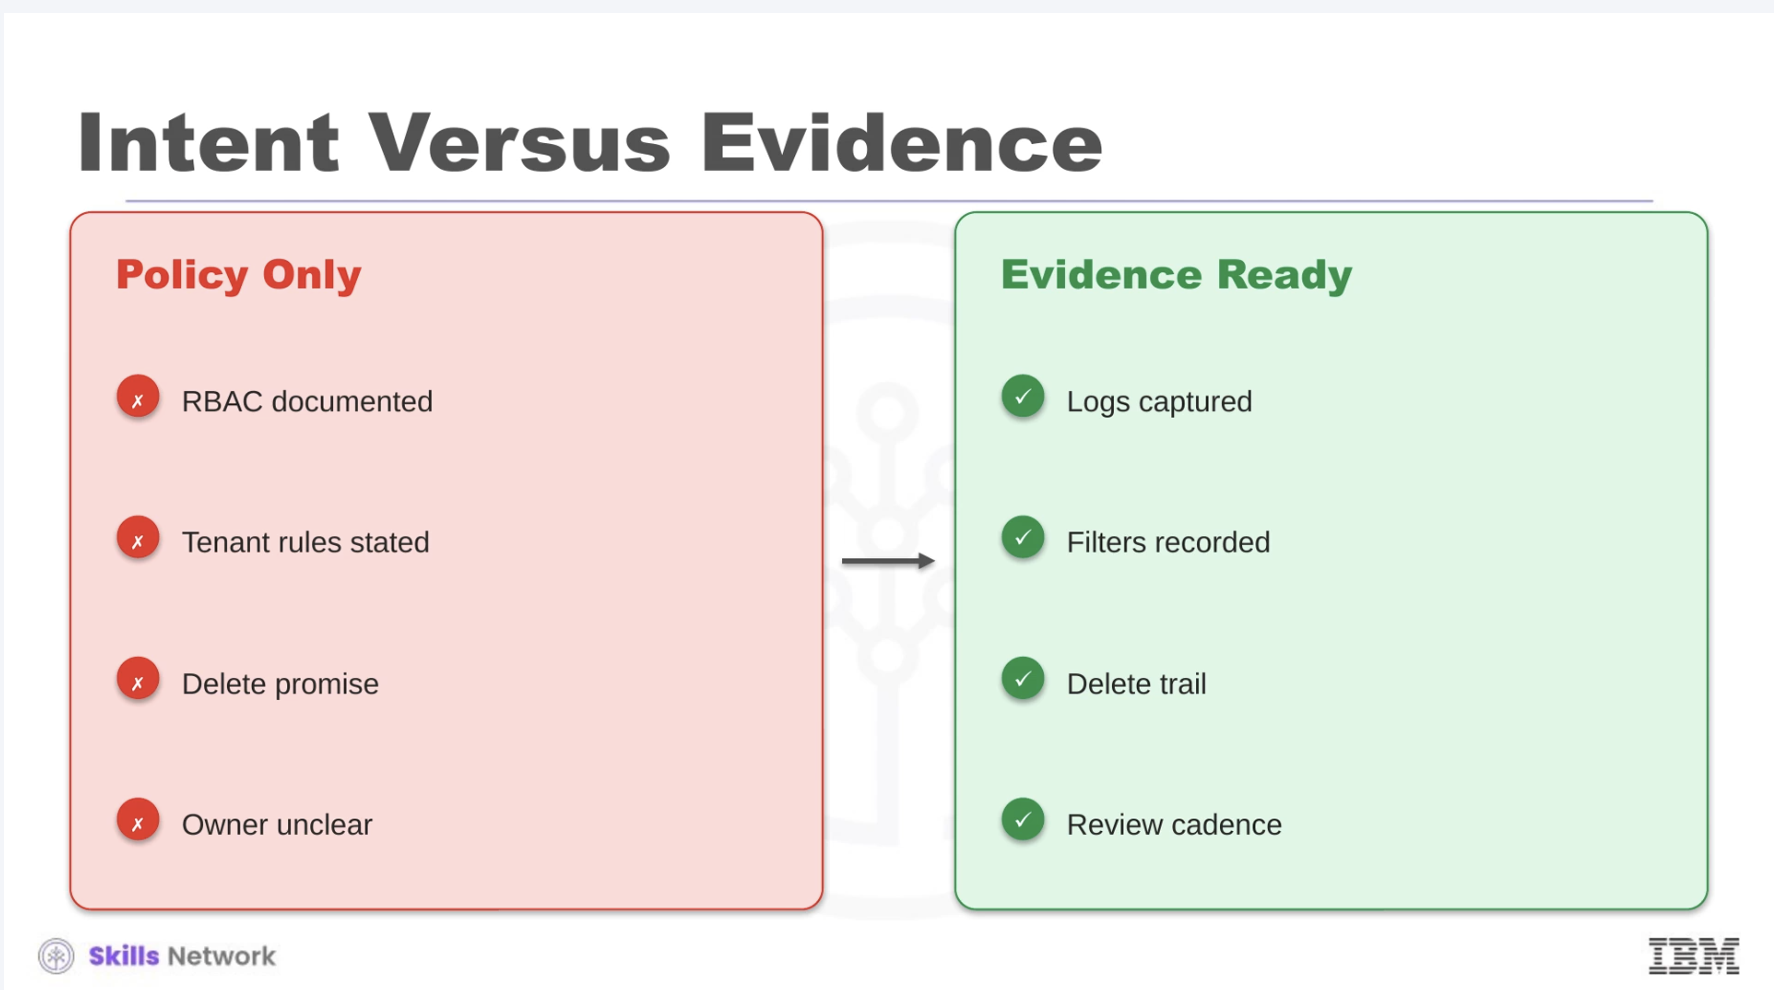
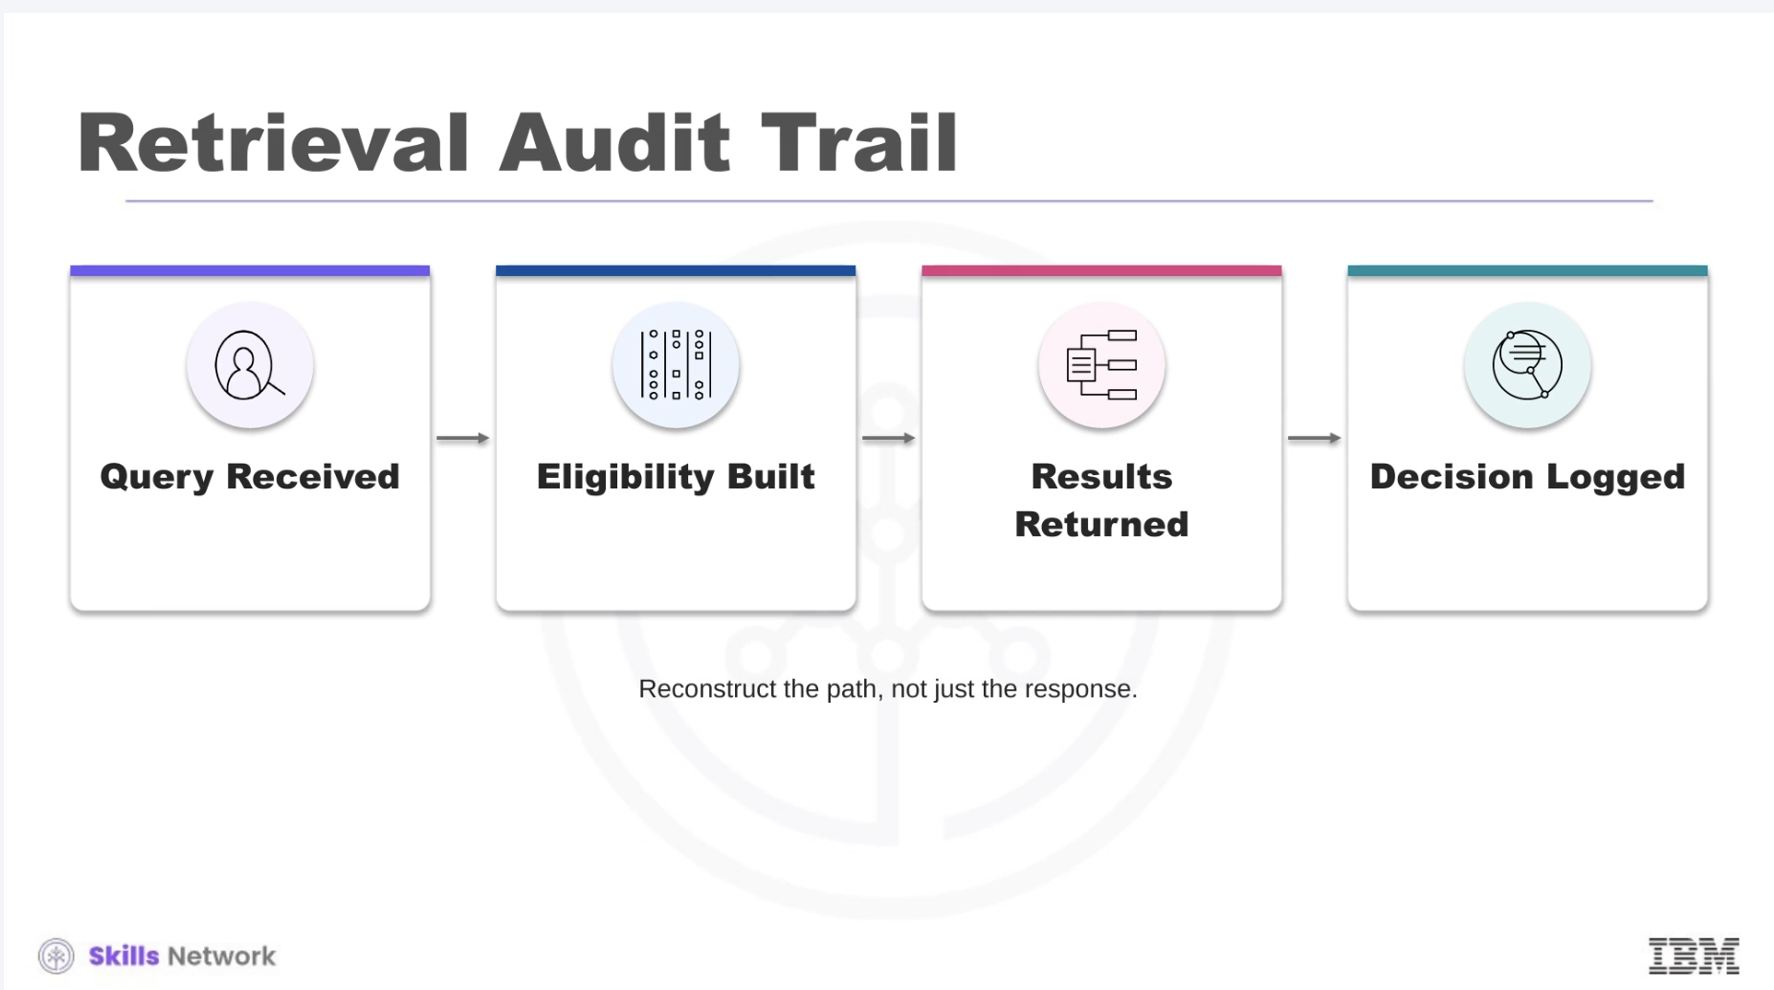
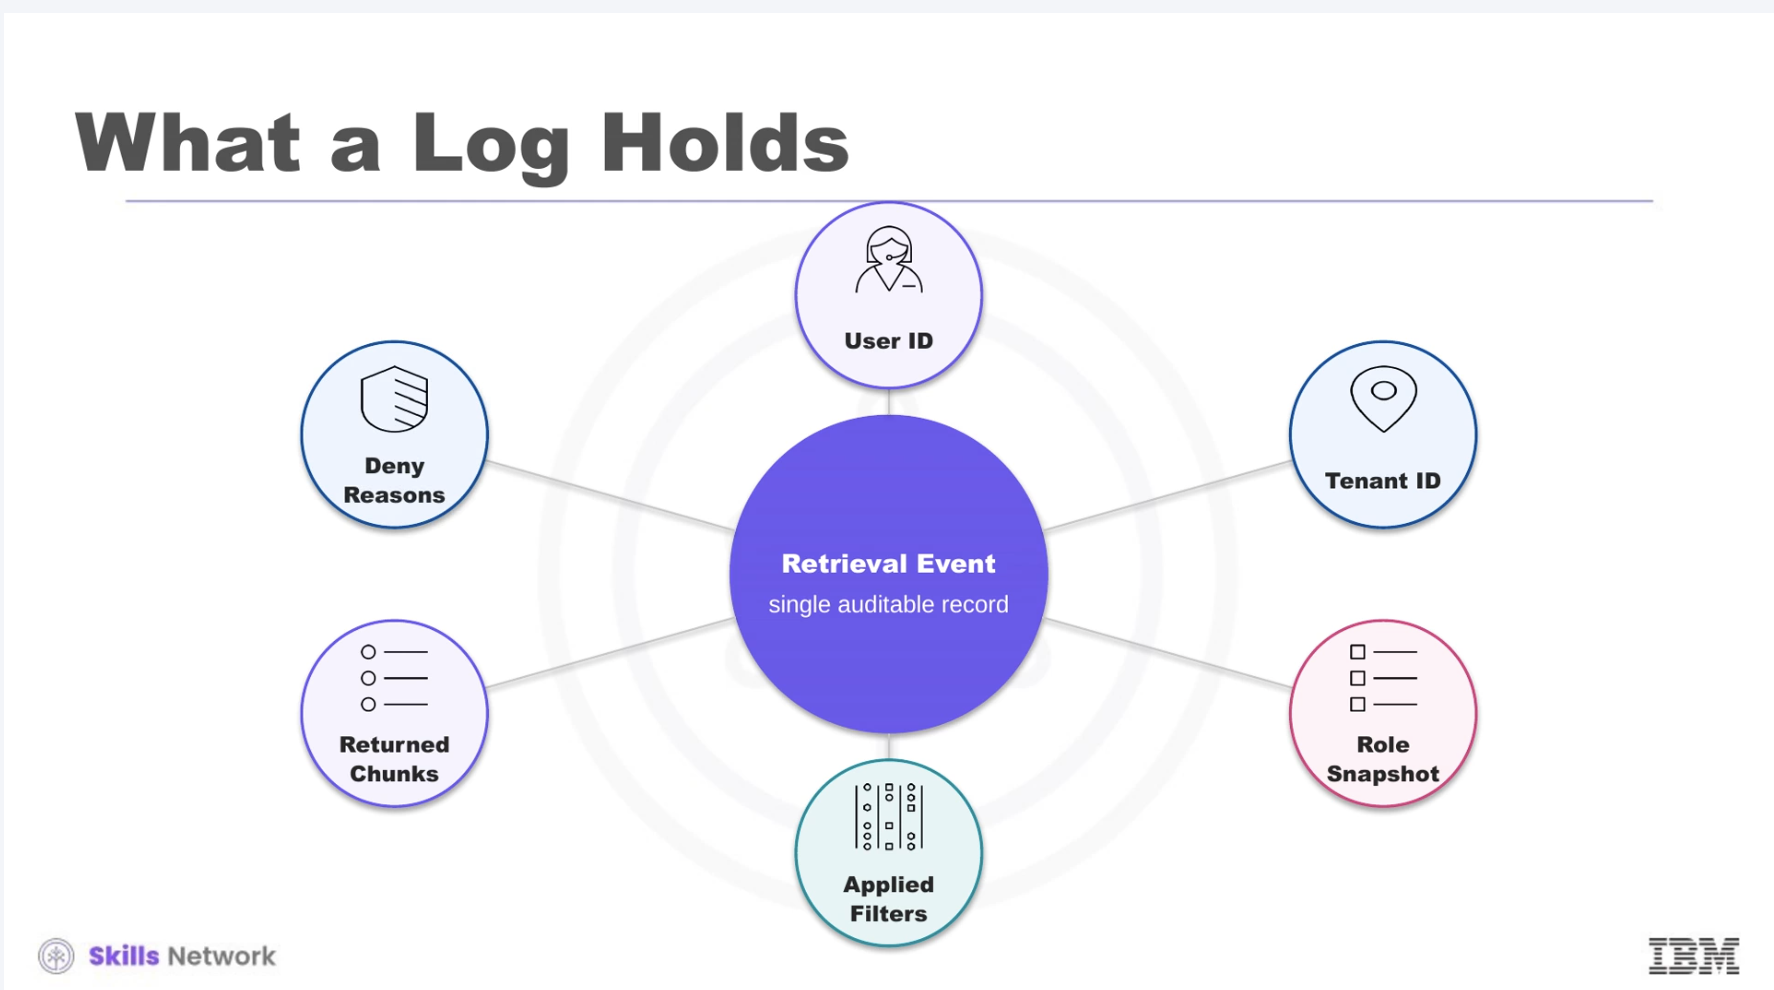
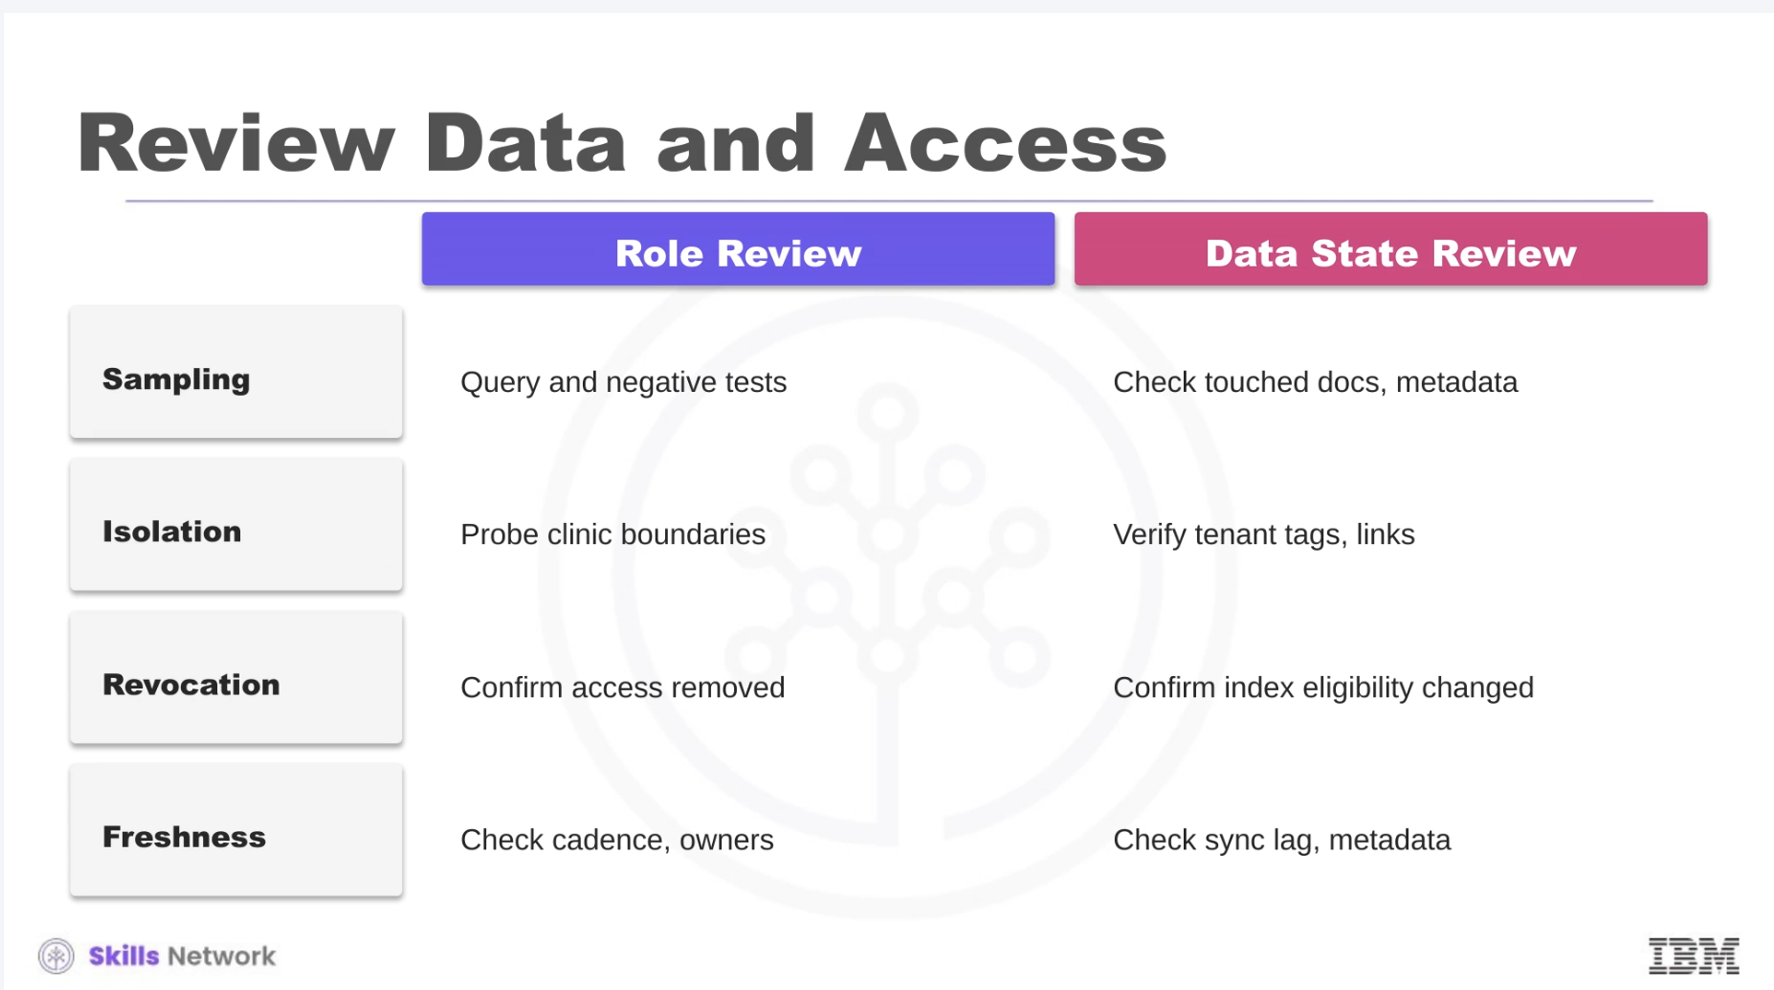
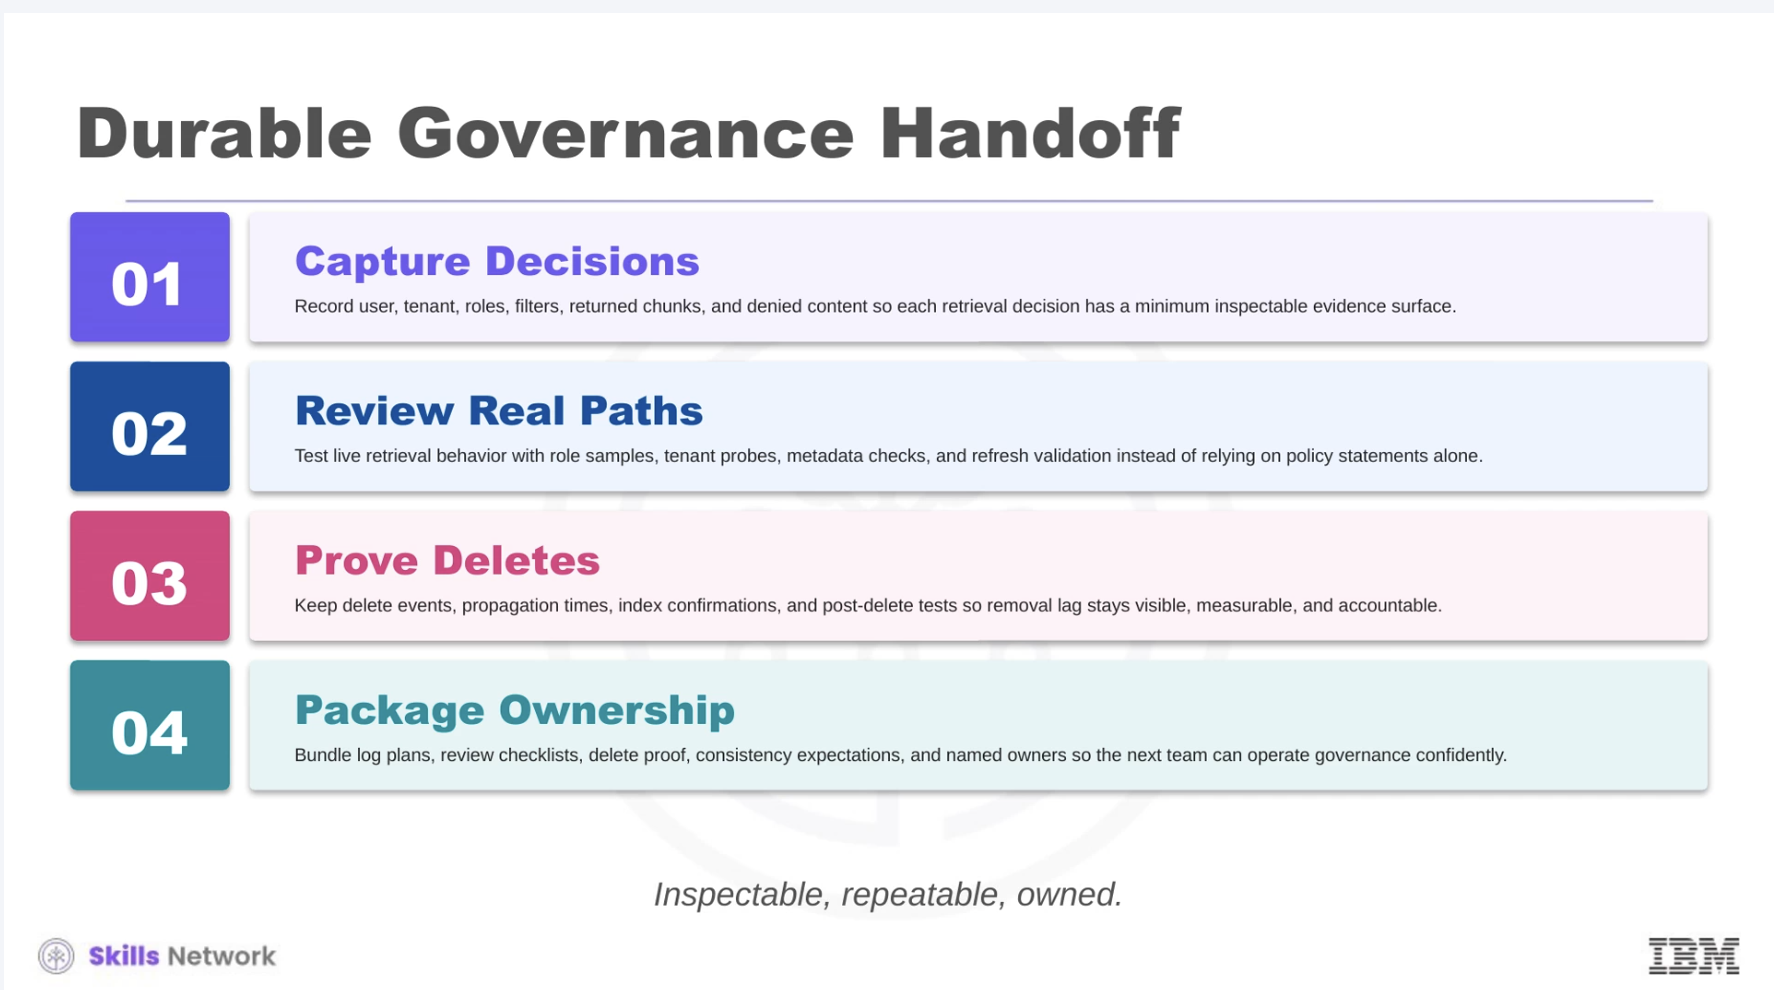